In [1]:
import os
import zipfile
from dotenv import load_dotenv
    
load_dotenv()

DATA_DIR = os.getenv("DATA_DIR")
ITEM = "diamond_sword"

PACKS_DIR = os.path.join(DATA_DIR, "packs")
ITEM_DIR = os.path.join(DATA_DIR, ITEM)
TARGET_SUFFIXES = [
    "assets/minecraft/textures/item/"+ITEM+".png",
    "assets/minecraft/textures/items/"+ITEM+".png",
]

print(ITEM_DIR)
print(PACKS_DIR)


D:\\alex's folder\\code\\mcproj\\data\diamond_sword
D:\\alex's folder\\code\\mcproj\\data\packs


Find most common item(s) across all texturepacks

In [2]:
from collections import Counter

ITEM_TEXTURE_DIRS = (
    "assets/minecraft/textures/item/",
    "assets/minecraft/textures/items/",
)

item_counts = Counter()

for file in os.listdir(PACKS_DIR):
    if not file.endswith(".zip"):
        continue

    zip_path = os.path.join(PACKS_DIR, file)
    with zipfile.ZipFile(zip_path, 'r') as zr:
        for name in zr.namelist():
            for prefix in ITEM_TEXTURE_DIRS:
                if name.startswith(prefix) and name.endswith(".png"):
                    item_name = name[len(prefix):-len(".png")]
                    item_counts[item_name] += 1
                    break

most_common = item_counts.most_common(10)
for item, count in most_common:
    print(f"{item}: {count}")


diamond_sword: 72
netherite_sword: 71
iron_sword: 63
stone_sword: 63
wooden_sword: 60
diamond_axe: 59
golden_sword: 57
netherite_axe: 57
ender_pearl: 55
bow_pulling_0: 53


Extracts `ITEM` from all texurepacks

In [3]:
ctr = 0

os.makedirs(ITEM_DIR, exist_ok=True)

for file in os.listdir(PACKS_DIR):
    if not file.endswith(".zip"):
        continue

    zip_path = os.path.join(PACKS_DIR, file)
    with zipfile.ZipFile(zip_path, 'r') as zr:
        names = zr.namelist()
        target = next((suffix for suffix in TARGET_SUFFIXES if suffix in names), None)
        if target is not None:
            # Read the bytes and write straight to the final path
            new_path = os.path.join(ITEM_DIR, f"{ITEM}_{ctr}.png")
            with zr.open(target) as src, open(new_path, "wb") as dst:
                dst.write(src.read())
            ctr += 1


Resizing Item to (32,32)

In [4]:
import os
from PIL import Image

TARGET_SIZE = (32, 32)

def process_item(path: str, filename: str) -> None:
    with Image.open(path) as img:
        img.load()  


    if img.size[0] != img.size[1]:
        print(f"[REMOVED] {filename}: not square {img.size}")
        os.remove(path)
        return

    if img.size != TARGET_SIZE:
        print(f"[RESIZED] {filename}: {img.size} -> {TARGET_SIZE}")
        img = img.resize(TARGET_SIZE, Image.Resampling.LANCZOS)
        img.save(path)


for sword in os.listdir(ITEM_DIR):
    if sword.endswith(".png"):
        process_item(os.path.join(ITEM_DIR, sword), sword)

[RESIZED] diamond_sword_10.png: (16, 16) -> (32, 32)
[RESIZED] diamond_sword_11.png: (16, 16) -> (32, 32)
[RESIZED] diamond_sword_12.png: (16, 16) -> (32, 32)
[RESIZED] diamond_sword_13.png: (16, 16) -> (32, 32)
[RESIZED] diamond_sword_17.png: (16, 16) -> (32, 32)
[RESIZED] diamond_sword_18.png: (16, 16) -> (32, 32)
[RESIZED] diamond_sword_19.png: (16, 16) -> (32, 32)
[RESIZED] diamond_sword_23.png: (16, 16) -> (32, 32)
[RESIZED] diamond_sword_24.png: (128, 128) -> (32, 32)
[RESIZED] diamond_sword_26.png: (16, 16) -> (32, 32)
[RESIZED] diamond_sword_29.png: (16, 16) -> (32, 32)
[RESIZED] diamond_sword_30.png: (16, 16) -> (32, 32)
[RESIZED] diamond_sword_37.png: (16, 16) -> (32, 32)
[RESIZED] diamond_sword_41.png: (16, 16) -> (32, 32)
[RESIZED] diamond_sword_42.png: (16, 16) -> (32, 32)
[RESIZED] diamond_sword_43.png: (16, 16) -> (32, 32)
[RESIZED] diamond_sword_45.png: (16, 16) -> (32, 32)
[RESIZED] diamond_sword_46.png: (16, 16) -> (32, 32)
[RESIZED] diamond_sword_57.png: (16, 16) -> 

display 10 random swords

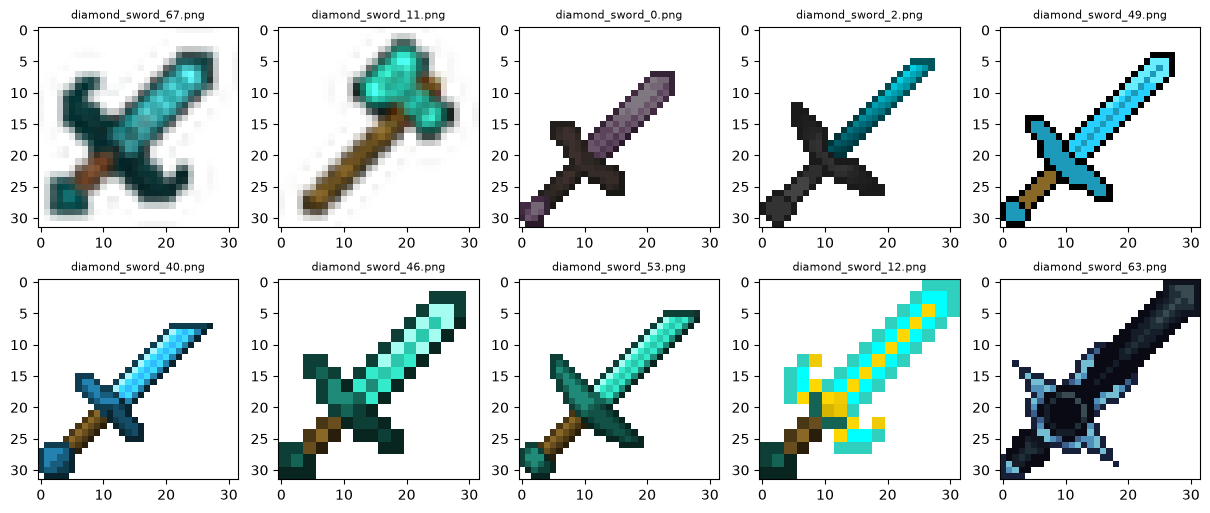

In [5]:
import random
import matplotlib.pyplot as plt

sword_files = [f for f in os.listdir(ITEM_DIR) if f.endswith(".png")]
sample = random.sample(sword_files, min(10, len(sword_files)))

cols = 5
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(15, 6))
axes = axes.flatten()

for i, sword in enumerate(sample):
    img = Image.open(os.path.join(ITEM_DIR, sword))
    axes[i].imshow(img)
    axes[i].set_title(sword, fontsize=8)



plt.show()